In [1]:
#Find the data files
import os 
for root,_,files in os.walk("/kaggle/input"):
    for f in files:
        print(os.path.join(root,f))

/kaggle/input/datasets/shayanfazeli/heartbeat/ptbdb_abnormal.csv
/kaggle/input/datasets/shayanfazeli/heartbeat/ptbdb_normal.csv
/kaggle/input/datasets/shayanfazeli/heartbeat/mitbih_test.csv
/kaggle/input/datasets/shayanfazeli/heartbeat/mitbih_train.csv


In [2]:
#Data loading & tensor making
import pandas as pd, numpy as np, torch
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset,DataLoader
TRAIN_PATH="/kaggle/input/datasets/shayanfazeli/heartbeat/mitbih_train.csv"
TEST_PATH="/kaggle/input/datasets/shayanfazeli/heartbeat/mitbih_test.csv"

train=pd.read_csv(TRAIN_PATH,header=None)
test=pd.read_csv(TEST_PATH,header=None)

X=train.iloc[:,:187].values.astype(np.float32)
y=train[187].values.astype(np.int64)
X_test=test.iloc[:,:187].values.astype(np.float32)
y_test=test[187].values.astype(np.int64)

#Holding 10% of the train set as validation set(stratified keeps class ratios equal)
X_tr,X_val,y_tr,y_val=train_test_split(X,y,test_size=0.1,stratify=y,random_state=42)
    
def to_loader(X,y,shuffle):
    X_t=torch.from_numpy(X).unsqueeze(1) #(N,187) -> (N,1,187)
    y_t=torch.from_numpy(y)
    return DataLoader(TensorDataset(X_t,y_t),batch_size=128,shuffle=shuffle)
train_loader=to_loader(X_tr,y_tr,shuffle=True)
val_loader=to_loader(X_val,y_val,shuffle=True)
test_loader=to_loader(X_test,y_test,shuffle=True)

xb,yb=next(iter(train_loader))
print(xb.shape,yb.shape)

torch.Size([128, 1, 187]) torch.Size([128])


In [3]:
#define the CNN
import torch.nn as nn

class ECGCNN(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=5, padding=2),  nn.ReLU(), nn.MaxPool1d(2),   # 187 -> 93
            nn.Conv1d(16, 32, kernel_size=5, padding=2), nn.ReLU(), nn.MaxPool1d(2),   # 93 -> 46
            nn.Conv1d(32, 64, kernel_size=5, padding=2), nn.ReLU(), nn.MaxPool1d(2),   # 46 -> 23
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),                    # (64 channels * 23 steps) = 1472 values
            nn.Linear(64 * 23, 64), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes),      # 5 scores, one per heartbeat class
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = ECGCNN()
print(model)
print("Parameters:", sum(p.numel() for p in model.parameters()))

ECGCNN(
  (features): Sequential(
    (0): Conv1d(1, 16, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (7): ReLU()
    (8): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1472, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=5, bias=True)
  )
)
Parameters: 107589


In [4]:
#shape check with a real batch
model.eval()
with torch.no_grad():
    out = model(xb)
print(out.shape)

torch.Size([128, 5])


In [5]:
#device and class weights
import torch, torch.nn as nn, numpy as np
from sklearn.metrics import f1_score

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

counts = np.bincount(y_tr, minlength=5)
weights = len(y_tr) / (5 * counts)        # same "balanced" formula as sklearn
print("class counts: ", counts)
print("class weights:", weights.round(2))
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

Using: cuda
class counts:  [65223  2001  5209   577  5788]
class weights: [ 0.24  7.88  3.03 27.31  2.72]


In [6]:
#model, loss function, optimizer
model = ECGCNN().to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [9]:
#one training epoch, and one evaluation pass
def train_one_epoch(model, loader):
    model.train()                                   # Dropout ON
    total_loss, correct, n = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)       # move the batch to the GPU
        optimizer.zero_grad()                       # 1. clear old gradients
        logits = model(xb)                          # 2. forward pass: get 5 scores per beat
        loss = criterion(logits, yb)                # 3. how wrong were we?
        loss.backward()                             # 4. backprop: compute gradients
        optimizer.step()                            # 5. nudge the weights
        total_loss += loss.item() * len(yb)         # (weighted-loss average is approximate, fine for trends)
        correct += (logits.argmax(1) == yb).sum().item()
        n += len(yb)
    return total_loss / n, correct / n

@torch.no_grad()                                    # no gradients needed when only evaluating
def evaluate(model, loader):
    model.eval()                                    # Dropout OFF
    total_loss, n = 0.0, 0
    preds, labels = [], []
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        total_loss += criterion(logits, yb).item() * len(yb)
        n += len(yb)
        preds.append(logits.argmax(1).cpu())
        labels.append(yb.cpu())
    preds, labels = torch.cat(preds).numpy(), torch.cat(labels).numpy()
    acc = (preds == labels).mean()
    macro_f1 = f1_score(labels, preds, average="macro")
    return total_loss / n, acc, macro_f1

In [10]:
#the training loop
EPOCHS = 15
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_f1": []}
best_f1 = 0.0

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader)
    va_loss, va_acc, va_f1 = evaluate(model, val_loader)

    for k, v in zip(history, [tr_loss, va_loss, tr_acc, va_acc, va_f1]):
        history[k].append(v)

    saved = ""
    if va_f1 > best_f1:                              # keep the best model so far
        best_f1 = va_f1
        torch.save(model.state_dict(), "/kaggle/working/ecg_model.pth")
        saved = "  <- saved"

    print(f"Epoch {epoch:2d} | train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
          f"val loss {va_loss:.4f} acc {va_acc:.4f} macro-F1 {va_f1:.4f}{saved}")

Epoch  1 | train loss 0.7713 acc 0.6605 | val loss 0.4509 acc 0.8134 macro-F1 0.6023  <- saved
Epoch  2 | train loss 0.4646 acc 0.8141 | val loss 0.3855 acc 0.8101 macro-F1 0.6219  <- saved
Epoch  3 | train loss 0.3887 acc 0.8343 | val loss 0.2989 acc 0.8762 macro-F1 0.6736  <- saved
Epoch  4 | train loss 0.3477 acc 0.8573 | val loss 0.2936 acc 0.9083 macro-F1 0.7138  <- saved
Epoch  5 | train loss 0.3111 acc 0.8689 | val loss 0.2669 acc 0.8880 macro-F1 0.6882
Epoch  6 | train loss 0.2856 acc 0.8768 | val loss 0.2390 acc 0.9079 macro-F1 0.7174  <- saved
Epoch  7 | train loss 0.2576 acc 0.8848 | val loss 0.2497 acc 0.9362 macro-F1 0.7720  <- saved
Epoch  8 | train loss 0.2474 acc 0.8912 | val loss 0.2424 acc 0.8904 macro-F1 0.7009
Epoch  9 | train loss 0.2318 acc 0.8918 | val loss 0.2433 acc 0.9260 macro-F1 0.7472
Epoch 10 | train loss 0.2180 acc 0.8941 | val loss 0.2068 acc 0.9108 macro-F1 0.7255
Epoch 11 | train loss 0.1983 acc 0.9026 | val loss 0.2165 acc 0.9302 macro-F1 0.7541
Epoch

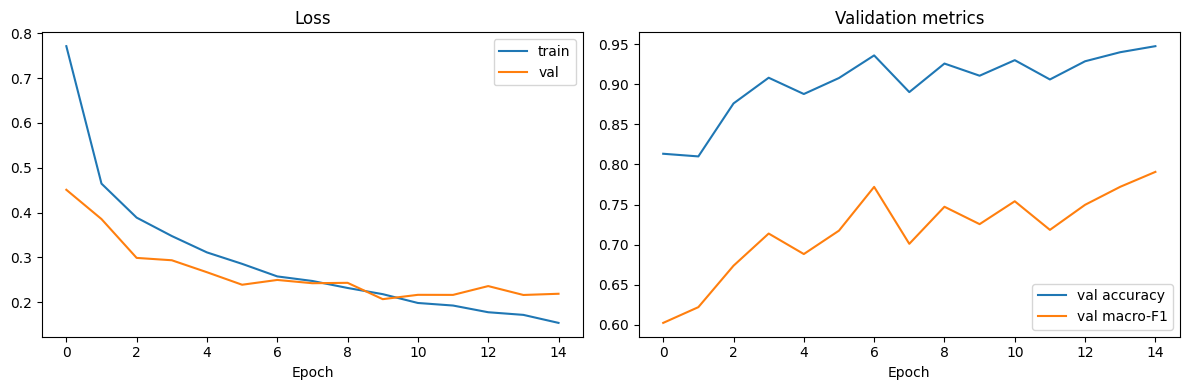

In [12]:
#learning curves
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history["train_loss"], label="train"); ax[0].plot(history["val_loss"], label="val")
ax[0].set_title("Loss"); ax[0].set_xlabel("Epoch"); ax[0].legend()
ax[1].plot(history["val_acc"], label="val accuracy"); ax[1].plot(history["val_f1"], label="val macro-F1")
ax[1].set_title("Validation metrics"); ax[1].set_xlabel("Epoch"); ax[1].legend()
plt.tight_layout(); plt.show()

In [13]:
#fresh model, with a learning-rate scheduler
import torch, torch.nn as nn

torch.manual_seed(42)
model = ECGCNN().to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=3)   # halve the LR if val macro-F1 stalls for 3 epochs

In [14]:
#train for 40 epochs, keep the best checkpoint
EPOCHS = 40
history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_f1": []}
best_f1 = 0.0

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader)
    va_loss, va_acc, va_f1 = evaluate(model, val_loader)
    scheduler.step(va_f1)

    for k, v in zip(history, [tr_loss, va_loss, va_acc, va_f1]):
        history[k].append(v)

    saved = ""
    if va_f1 > best_f1:
        best_f1 = va_f1
        torch.save(model.state_dict(), "/kaggle/working/ecg_model.pth")
        saved = "  <- saved"

    lr = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch:2d} | train loss {tr_loss:.4f} | val loss {va_loss:.4f} "
          f"acc {va_acc:.4f} F1 {va_f1:.4f} | lr {lr:.5f}{saved}")

Epoch  1 | train loss 0.7720 | val loss 0.4517 acc 0.8201 F1 0.6089 | lr 0.00100  <- saved
Epoch  2 | train loss 0.4664 | val loss 0.3878 acc 0.8001 F1 0.6139 | lr 0.00100  <- saved
Epoch  3 | train loss 0.3913 | val loss 0.2994 acc 0.8804 F1 0.6787 | lr 0.00100  <- saved
Epoch  4 | train loss 0.3522 | val loss 0.2958 acc 0.9141 F1 0.7215 | lr 0.00100  <- saved
Epoch  5 | train loss 0.3155 | val loss 0.2709 acc 0.8892 F1 0.6924 | lr 0.00100
Epoch  6 | train loss 0.2934 | val loss 0.2416 acc 0.9181 F1 0.7313 | lr 0.00100  <- saved
Epoch  7 | train loss 0.2647 | val loss 0.2616 acc 0.9429 F1 0.7887 | lr 0.00100  <- saved
Epoch  8 | train loss 0.2509 | val loss 0.2262 acc 0.9108 F1 0.7277 | lr 0.00100
Epoch  9 | train loss 0.2372 | val loss 0.2445 acc 0.9307 F1 0.7544 | lr 0.00100
Epoch 10 | train loss 0.2146 | val loss 0.2143 acc 0.9036 F1 0.7159 | lr 0.00100
Epoch 11 | train loss 0.2022 | val loss 0.2253 acc 0.9263 F1 0.7466 | lr 0.00050
Epoch 12 | train loss 0.1746 | val loss 0.2181 ac

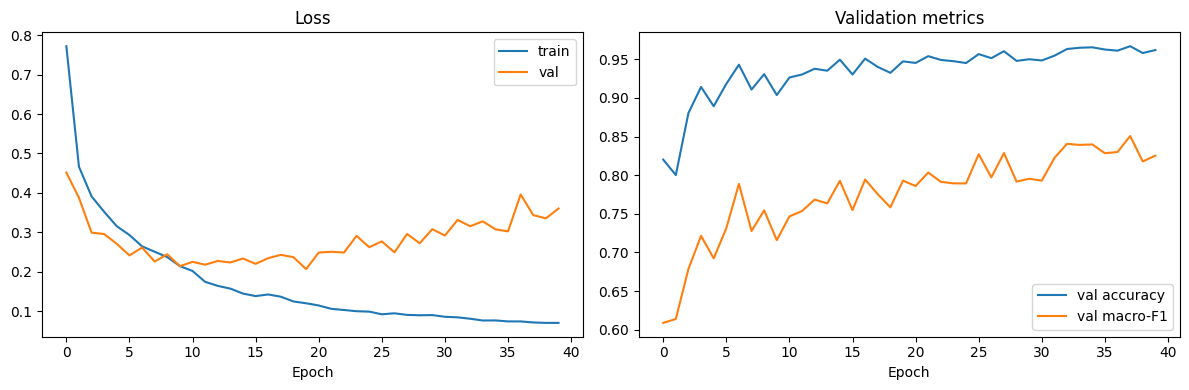

In [15]:
#learning curves
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history["train_loss"], label="train"); ax[0].plot(history["val_loss"], label="val")
ax[0].set_title("Loss"); ax[0].set_xlabel("Epoch"); ax[0].legend()
ax[1].plot(history["val_acc"], label="val accuracy"); ax[1].plot(history["val_f1"], label="val macro-F1")
ax[1].set_title("Validation metrics"); ax[1].set_xlabel("Epoch"); ax[1].legend()
plt.tight_layout(); plt.show()

              precision    recall  f1-score   support

           N      0.994     0.963     0.978     18118
           S      0.527     0.847     0.650       556
           V      0.896     0.951     0.923      1448
           F      0.548     0.877     0.675       162
           Q      0.972     0.989     0.981      1608

    accuracy                          0.961     21892
   macro avg      0.788     0.926     0.841     21892
weighted avg      0.971     0.961     0.964     21892



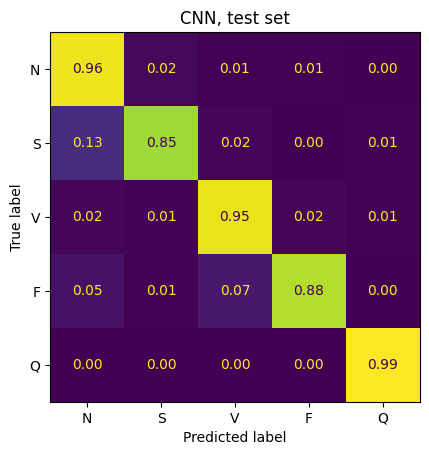

{'accuracy': 0.960944637310433, 'macro_f1': 0.8413617419478671}


In [16]:
#final evaluation on the TEST set (do this once)
import json
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

model.load_state_dict(torch.load("/kaggle/working/ecg_model.pth", map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        all_preds.append(model(xb.to(device)).argmax(1).cpu())
        all_labels.append(yb)
preds = torch.cat(all_preds).numpy()
labels = torch.cat(all_labels).numpy()

names = ["N", "S", "V", "F", "Q"]
print(classification_report(labels, preds, target_names=names, digits=3))

cm = confusion_matrix(labels, preds, normalize="true")
ConfusionMatrixDisplay(cm, display_labels=names).plot(values_format=".2f", colorbar=False)
plt.title("CNN, test set"); plt.show()

results = {"accuracy": float((preds == labels).mean()),
           "macro_f1": float(f1_score(labels, preds, average="macro"))}
print(results)
with open("/kaggle/working/cnn_results.json", "w") as f:
    json.dump(results, f, indent=2)

In [17]:
# will this file work on a CPU-only server like Render?
import os
cpu_model = ECGCNN()
cpu_model.load_state_dict(torch.load("/kaggle/working/ecg_model.pth", map_location="cpu"))
cpu_model.eval()

sample = torch.from_numpy(X_test[:1]).unsqueeze(1)          # one beat, shape (1, 1, 187)
with torch.no_grad():
    probs = torch.softmax(cpu_model(sample), dim=1)
print("probabilities:", probs.numpy().round(3), "| true label:", y_test[0])
print("file size (KB):", os.path.getsize("/kaggle/working/ecg_model.pth") / 1024)

probabilities: [[1. 0. 0. 0. 0.]] | true label: 0
file size (KB): 424.7236328125
